In [22]:
# öppna och hantera zip-arkiv (extrahera dataset)
import zipfile
# styr mappar och filer på datorn 
import os

In [23]:
# vart zip-filen ligger, archive.zip = deladdade dataset-fil
zip_path = "archive.zip"
# "data" = mapp där allt ska hamna
extract_path = "data" 

# öppna, läs och stäng automatiskt efteråt. alla filer i zip-filen flyttas till mapp data
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [24]:
# pandas används för tabeller (dataframes)
import pandas as pd

# används för att skapa diagram
import matplotlib.pyplot as plt

# snyggare statistikdiagram ovanpå matplotlib
import seaborn as sns

# mörk bakgrund = snyggare
sns.set_style("darkgrid")

# df = hela spotify dataseteti tabellform
df = pd.read_csv("data/dataset.csv")

# rensa onödig kolumn 
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# visa data, 5 första raderna
df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Vilka är de mest populära låtarna ?

Nedan kommer jag sortera låtar eftar popularitet och visa topp 10 

In [25]:
# märkte att de fanns flera av samma låtar + artist men olika id så tar bort alla dublikat av låt namn + artist
df = df.drop_duplicates(subset=["track_name", "artists"])

# väljer att analysera låt, artist, populäritet. Tar ut de tio mest populära låtarna och sortera på popularity, högst först
df[['track_name', 'artists', 'popularity']].sort_values(by='popularity',
 ascending=False
).head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
67359,Tití Me Preguntó,Bad Bunny,97
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
20000,Under The Influence,Chris Brown,96
67559,Efecto,Bad Bunny,96
79000,I Ain't Worried,OneRepublic,96
67500,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95


# Genre vs Popularity
I denna analys undersöker jag vilka musikgenrer som har högst genomsnittlig popularitet på spotify 

Genom att gruppera låtar efter genre och beräkna medelvälrde av popularitet kan vi se vilka musiktitlar som genrellet lyssnas mest på. 

Detta ger en bättre bild än att bara tittat på enskilda låtar, eftersom det visar övergripande trender i lyssningsbeteende. 

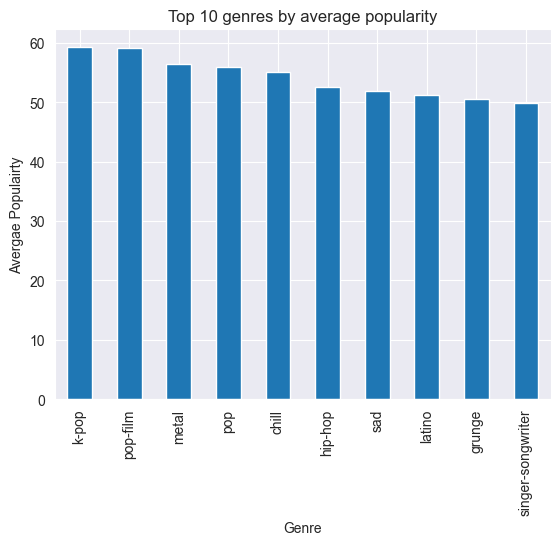

In [26]:
# gruppera per genre, räkna medelvärde på popularity
genre_popularity = df.groupby("track_genre")["popularity"].mean()

# sortera högst först
genre_popularity = genre_popularity.sort_values(ascending=False)

# ta top 10
top_genres = genre_popularity.head(10)

# visualiserar genom barchart 
top_genres.plot(kind="bar")

plt.title("Top 10 genres by average popularity")
plt.xlabel("Genre")
plt.ylabel("Avergae Populairty")

plt.show()

## Genre Analysis: Popularity, Energy & Danceability

I denna analys undersöker jag de 10 mest populära musikgenrerna baserat på genomsnittlig popularitet.

För varje genre jämförs även två viktiga musikaliska egenskaper:
- **Energy**: hur intensiv och energisk musiken är
- **Danceability**: hur lätt låten är att dansa till

Genrerna har sorterats efter popularitet, men själva visualiseringen fokuserar på energy och danceability för att tydligare kunna jämföra musikaliska skillnader mellan genrer utan att popularitetsskalan påverkar diagrammet.

Detta gör det möjligt att se hur olika genrer skiljer sig åt i stil och känsla, inte bara i hur mycket de lyssnas på.

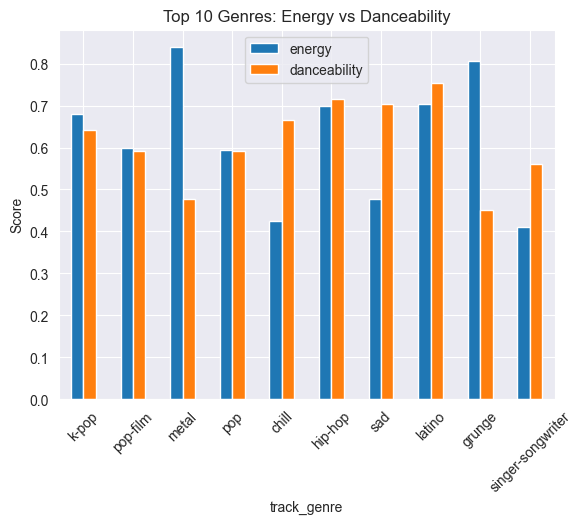

In [27]:
# grupperar per genre, räknar medelvärde på flera features för varje genre
genre_stats = df.groupby("track_genre")[["popularity","energy", "danceability"]].mean()

# väljer top 10 genres baserat på populairty
top_genres = genre_stats.sort_values(by="popularity", ascending=False).head(10)

# displayar energy och danceability i bar chart
top_genres[["energy", "danceability"]].plot(kind="bar")

# visualiserar (roation=45 gör index mer läsbara)
plt.title("Top 10 Genres: Energy vs Danceability")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Heatmap: Correlation Between Music Features

I denna analys undersöks hur olika musikaliska egenskaper i Spotify-datasetet hänger ihop.

Genom att beräkna korrelationen mellan variabler som energy, danceability, tempo och popularity kan vi identifiera mönster i vad som kännetecknar olika typer av musik.

Detta hjälper oss att förstå vilka egenskaper som tenderar att förekomma tillsammans, samt vilka som har motsatt samband.

Heatmapen visar dessa samband visuellt där starkare färger representerar starkare relationer mellan variablerna.

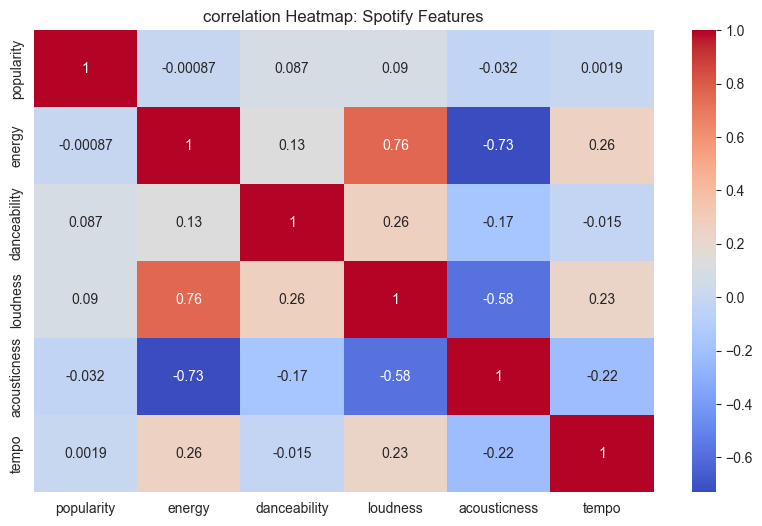

In [28]:
# väljer ut viktiga musikfeatures pch popularitet för analys
features = df[["popularity", "energy", "danceability", "loudness", "acousticness", "tempo"]]

# räkna korrelationer mellan alla valda features
# detta visar hur starkt samband variblerna har med varandra
corr = features.corr()

# skapa figur med passande storlek 
plt.figure(figsize=(10, 6))
# visualiserar korrealtionsmatrisen mha heatmap 
# annot=True visar siffror i varje ruta, coolwarm ger färgskala
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("correlation Heatmap: Spotify Features")
plt.show()

Sammanfattningsvis visar heatmapen att vissa musikaliska egenskaper, såsom energy och loudness, har starka samband, medan andra variabler som tempo och popularity är mer oberoende.

Detta indikerar att vissa delar av musiken är starkt kopplade till hur låten upplevs, medan andra faktorer påverkas av fler variabler.

# Vad kännetecknar en hit-låt?

I denna analys undersöker jag vad som kännetecknar en “hit-låt” i Spotify-datasetet.

En låt definieras som en hit om den ligger bland de 25% mest populära låtarna i datasetet.

Genom att jämföra dessa låtar med resten av datasetet kan vi identifiera skillnader i musikaliska egenskaper såsom energy, danceability, tempo och loudness.

Syftet är att hitta mönster som kan ge en indikation på vilka faktorer som ofta förekommer i populära låtar, även om det inte nödvändigtvis innebär orsakssamband.


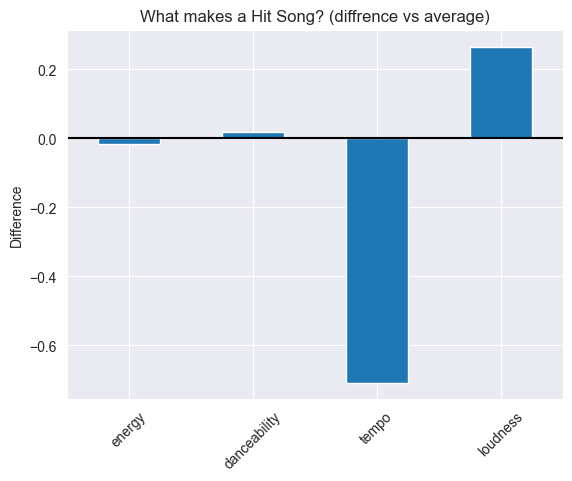

In [29]:
threshold = df["popularity"].quantile(0.75)

# skapar en dataframe med bara hits
hits = df[df["popularity"] >= threshold]

# Beräknar medelvärde på core features
features = ["energy", "danceability", "tempo", "loudness"]

# medelvärde av features för hits
hits_mean = hits[features].mean()

# medelvärde av features för alla låtar 
all_mean = df[features].mean()

comparison = hits_mean - all_mean
comparison 

comparison.plot(kind="bar")

plt.title("What makes a Hit Song? (diffrence vs average)")
plt.ylabel("Difference")
plt.xticks(rotation=45)
plt.axhline(0, color="black")
plt.show()

Analysen visar att hit-låtar i datasetet tenderar att vara mer högljudda och något mer dansbara än genomsnittet.

Samtidigt har de något lägre tempo och något lägre energy än genomsnittet, vilket antyder att populära låtar inte nödvändigtvis är de mest intensiva eller snabba.

Detta tyder på att popularitet inte enbart drivs av energi, utan snarare av en kombination av ljudstyrka och rytmiska egenskaper.

# Vilken genre producerar flest hit-låtar?

I denna analys undersökt vilka musikgenrer som förekommer mest bland de mest populära låtarna i datasetet. 

En hit defineras än en gång som en låt som tillhör de 25% mest populära låtarna baserat påspotify´s popularity-score.

Genom att analysera vilka genrer som dominerar bland dessa låtar kan vi identifiera vilka musikstilar som oftast producerar framgångsrika och populära låtar på spotify.

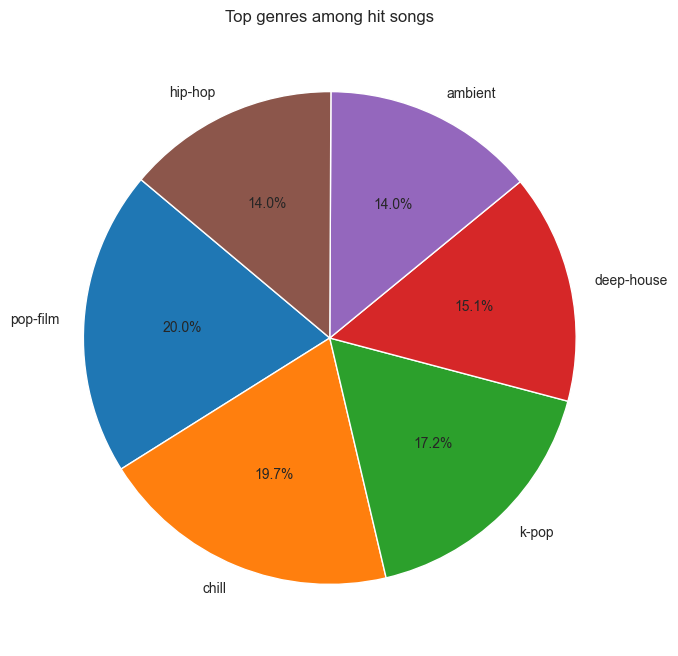

In [30]:
# Räkna ut hur många gånger varje genre finns i hits och tar de 8 största 
hit_genres = hits["track_genre"].value_counts().head(6)


plt.figure(figsize=(8, 8))

plt.pie(
    hit_genres.values,
    labels=hit_genres.index ,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top genres among hit songs")
plt.show()

#  top_genres, = själva datan
#  labels=top_genres.index , = visar namn på varje slice
#  autopct="%1.1f%%", = visar procent på varje bit 
#  startangle=140 = roterar cirkeln så den börjar snyggare

# Distribution av "danceability"
I denna anlys undersöker jag hur "dansbara" låtarna i spotify-datasetet är. 

Danceability är ett värde mellan 0 och 1 som beskriver hur lätt en låt är att dansa till, baserat på rytm, tempo och takt.

Genom att visualisera fördelningen med ett histogram kan jag se hur musikens dansbarhet är fördelad i datasette och om de finns tydliga mönster.

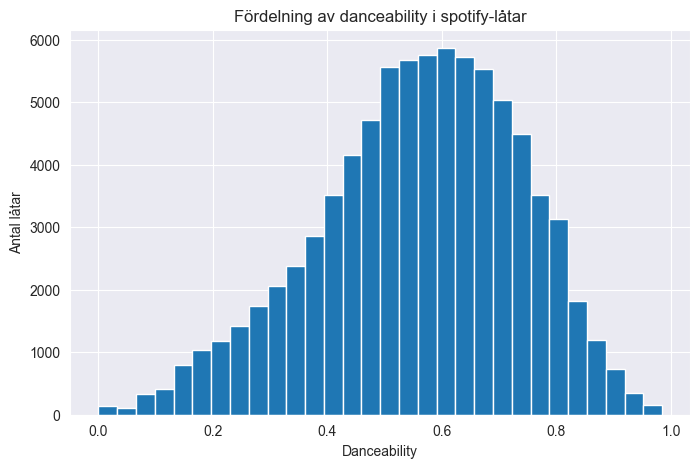

In [32]:
plt.figure(figsize=(8,5))

# rita histogram över danceability
# bins = antal intervaller(hur finfördelad grafen ska vara)
plt.hist(df["danceability"], bins=30)

plt.title("Fördelning av danceability i spotify-låtar")
plt.xlabel("Danceability")
plt.ylabel("Antal låtar")
plt.show()

Med hjälp av diagrammet visas de att distributionen är centrerad runt mitten. 

Det innebär att de flesta låtar har en danceability i ett medelintervall, snarare än att ligga i extremvärden. Spotify innehåller därför mycket "balanserad mainstream musik", inte extremt experiminetiell eller bara ren dansmusik. 

En möjlig musikmässig tolkning är att en danceability mellan 0.5-0.7 motsvarar typisk radio musik eller spotify-pop som är anpassad för en bred publik. 

Detta kan tyda på att Spotify som plattform inte främst fokuserar på extremt nischad musik, utan snarare på låtar som fungerar för en stor och varierad lyssnargrupp.

# Smaband mellan energi och popularitet
I denna analys udnersöker jag sambandet mellan två features i datasetet, energy och popularity.

Målet är med visualiseringen är att undersöka om de finns ett mönster eller samband mellan energin i en låt och dess popularitet. 

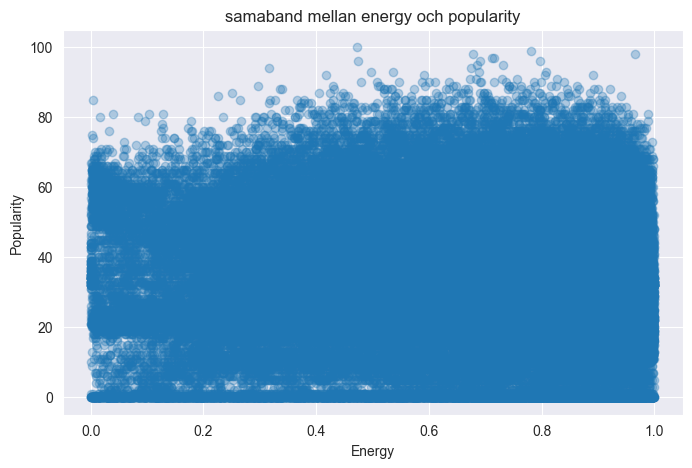

In [ ]:
plt.figure(figsize=(8,5))

# scatter plot mellan energy och popularity
# alpha=0.3 = ganska genomskinliga punkter 30% synlig
plt.scatter(df["energy"], df["popularity"], alpha=0.3)

plt.title("samaband mellan energy och popularity")

plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.show()

Scattern ploten visar sambandet mellan energy och popularity för alla låtar i datasetet. Varje punkt representerar en låt. 

Resultatet visar ingen tydlig linjär trend mellan energy och popularitet. Låtar med med både låg och hög energy kan ha både hög och låg popularitet. 

Detta tyder på att energy i sig inte är en stark indikator på om en låt blir populär, utan att popularitet sannolikt påverkar av flera kombinerade faktorer. 

# Analys av tempo med boxplot

I denna analys används en boxplot för att underöska fördelnignen av varibeln "tempo" i datasetet.

Vad är tempo? De beskriver hastigheten på en låt och mäts i BMP (beats/minut). Högre värde = snabbare musik.

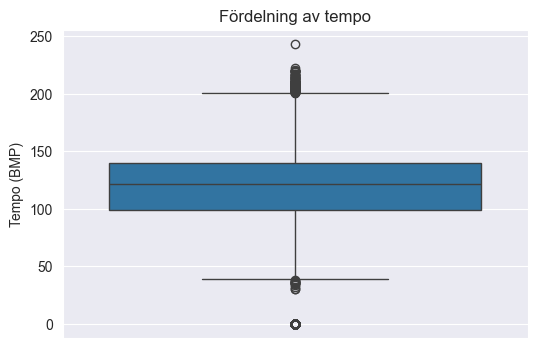

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["tempo"])

plt.title("Fördelning av tempo")
plt.ylabel("Tempo (BMP)")
plt.show()

Tolknign av boxploten

Medianen ligger omkring 120 BPM, vilket tyder på att många låtar i datasetet har ett medelhögt tempo. Den största delen av låtarna verkar ligga mellan ungefär 100-140 BPM.

Diagrammet innehåller även flera outliers både över och under den normala spridningen. Vissa låtar har mycket högt tempo över 200 BPM medan några få låtar har mycket lågt tempo nära 0 BPM.

Detta visar att majoriteten av låtar har ett realtivt liknande tempo men att det också finns låtar som skiljer sig kraftigt från resten av datasetet.